# Correlation analysis - Single Video

In [170]:
#imports
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

## Select Candidates

In [171]:
# Select candidates 

person1 = 'Martins'
person2 = 'Gouveia_Melo'

## Load visual + audio for this debate


In [172]:
# Visual 
pklfiles_visual = []
for file in os.listdir('../Project_Features'):
    if file.endswith('visual.pkl') and person1 in file and person2 in file:
        pklfiles_visual.append(file)

visual_dfs = []
for video in pklfiles_visual:
    print(f"Loading visual: {video}")
    df = pd.read_pickle(os.path.join('../Project_Features', video))
    visual_dfs.append(df)

df_visual = pd.concat(visual_dfs, ignore_index=True)
df_visual['video'] = df_visual['Frame'].str.extract(r'Frames/([^/]+)/')
df_visual['frame_number'] = df_visual['Frame'].str.extract(r'frame_(\d+)\.jpg').astype(int)
df_visual = df_visual.sort_values(by=['video', 'frame_number']).reset_index(drop=True)

# Audio
pklfiles_audio = []
for file in os.listdir('../Project_Features'):
    if file.endswith('audio.pkl') and person1 in file and person2 in file:
        pklfiles_audio.append(file)

audio_dfs = []
for video in pklfiles_audio:
    print(f"Loading audio: {video}")
    df = pd.read_pickle(os.path.join('../Project_Features', video))
    df['video'] = video.replace('_audio.pkl', '')
    audio_dfs.append(df)

df_audio = pd.concat(audio_dfs, ignore_index=True)
df_audio = df_audio.sort_values(by=['video', 'time stamp']).reset_index(drop=True)

def parse_embedding(x):
    if isinstance(x, np.ndarray):
        return x
    return np.fromstring(str(x).strip('[]'), sep=' ')

df_audio['speak_embeddings'] = df_audio['speak_embeddings'].apply(parse_embedding)

Loading visual: Martins_vs_Gouveia_Melo_November_23_visual.pkl
Loading audio: Martins_vs_Gouveia_Melo_November_23_audio.pkl


In [173]:
NON_REDUNDANT = ['meanF0Hz','stdevF0Hz','HNR','localJitter','localShimmer',
                 'speechrate','npause','f1_mean','f2_mean','fdisp'] # from EDA

df_audio['time_end'] = df_audio['time stamp'] + df_audio['duration']

rows = []
for t in sorted(df_visual['frame_number'].unique()):
    active = df_audio[(df_audio['time stamp'] <= t) & (df_audio['time_end'] > t)]
    if len(active) == 1: # exactly one speaker this second
        seg = active.iloc[0]
        r = {'frame_number': int(t), 'has_audio': True, 'segment_id': int(active.index[0])}
        r.update({c: seg[c] for c in NON_REDUNDANT})
    else:
        r = {'frame_number': int(t), 'has_audio': False, 'segment_id': -1}
        r.update({c: np.nan for c in NON_REDUNDANT})
    rows.append(r)

# audio_by_frame: one row per video frame, with audio features, segment_id linking to df_audio, and has_audio flag
audio_by_frame = pd.DataFrame(rows)
print('frames total:', len(audio_by_frame))
print('frames with audio:', int(audio_by_frame['has_audio'].sum()))
print('distinct segments:', audio_by_frame.loc[audio_by_frame.has_audio, "segment_id"].nunique())

frames total: 2048
frames with audio: 1729
distinct segments: 99


## Per-face visual table (faces matched to bodies + pose features)

In [174]:
# same qb as visual_and_audio 
Y_CUT    = 450    
AREA_CUT = 8000

def is_interpreter(face, y_cut=Y_CUT, area_cut=AREA_CUT):
    x1, y1, x2, y2 = face['bbox']
    yc   = (y1 + y2) / 2
    area = (x2 - x1) * (y2 - y1)
    return (yc > y_cut) and (area < area_cut)   # BOTH low AND small

master_data = []

for index, row in df_visual.iterrows():
    frame_id = row['Frame']
    frame_number = row['frame_number']
    faces = row['Fer']
    poses = row['Poses'] 
    
    if isinstance(faces, list) and len(faces) > 0:
        #check if faces is a dict (and if it has bbox probbaly has the other keys)
        valid_faces = [f for f in faces if isinstance(f, dict) and 'bbox' in f]
        # filter - GESTUAL LANGUAGE 
        valid_faces = [f for f in valid_faces if not is_interpreter(f)]
    else:
        valid_faces =[]

    
    people_count = len(valid_faces)

    if 0<people_count <=3:

        for i, face in enumerate(valid_faces):
            # Face Coordinates
            f_box = face['bbox'] # [x1, y1, x2, y2]
            f_width = f_box[2] - f_box[0]
            f_height = f_box[3] - f_box[1]
            
            f_x_center = f_box[0] + (f_width / 2)
            f_y_center = f_box[1] + (f_height / 2) 
            face_area = f_width * f_height
            
            top_emotion = face.get('top_emotion')
            probability = face['probabilities'].get(top_emotion) if top_emotion and 'probabilities' in face else None
            landmarks = face.get('landmarks')
            
            # MATCH THE BODY TO THE FACE
            matched_body_bbox = None
            matched_pose_keypoints = None
            
            if isinstance(poses, list):
                for person_body in poses:
                    if isinstance(person_body, dict)and len(person_body) > 0:
                        b_box = person_body['bbox'] 
                        
                        # is the center of the face inside this body's bounding box?
                        #note that b_box[3] > bbox[1] because y axis goes down
                        if (b_box[0] <= f_x_center <= b_box[2]) and (b_box[1] <= f_y_center <= b_box[3]):
                            matched_body_bbox = b_box
                            matched_pose_keypoints = person_body.get('pose') # The 17x3 matrix
                            break 
            
            master_data.append({
                'frame': frame_id,
                'frame_number': frame_number,
                'people_count': people_count,
                'person_index': i,
                'face_X_center': f_x_center,
                'face_area': face_area,
                'face_bbox': f_box,
                'body_bbox': matched_body_bbox,
                'top_emotion': top_emotion,
                'landmarks': landmarks,
                'pose_keypoints': matched_pose_keypoints,
                **{f'prob_{e}': p for e, p in face['probabilities'].items()}})
            
    else:
        # Handle empty frames
        master_data.append({
            'frame': frame_id,
            'frame_number': frame_number,
            'people_count': 0,
            'person_index': None,
            'face_X_center': None,
            'face_area': None,
            'face_bbox': None,
            'body_bbox': None,
            'top_emotion': None,
            'landmarks': None,
            'pose_keypoints': None
        })
df_master = pd.DataFrame(master_data)
print(f"Important data (df shape): {df_master.shape}")
print(df_master['pose_keypoints'].isna().sum())
print(f"Total rows: {len(df_master)}")

Important data (df shape): (3261, 19)
30
Total rows: 3261


In [175]:
KEYPOINTS = {
    'nose': 0, 'left_eye': 1, 'right_eye': 2,
    'left_ear': 3, 'right_ear': 4,
    'left_shoulder': 5, 'right_shoulder': 6,
    'left_elbow': 7, 'right_elbow': 8,
    'left_wrist': 9, 'right_wrist': 10,
    'left_hip': 11, 'right_hip': 12
}

# Extract pose features for correlation with emotions
def extract_pose_features(keypoints):
    if keypoints is None:
        return pd.Series({
            'shoulder_slope': None,
            'body_openness': None,
            'head_tilt': None,
            'wrist_height': None,
            'torso_height': None
        })
    
    kp = np.array(keypoints) # 17x3: [x, y, visibility]
    
    l_shoulder = kp[5]
    r_shoulder = kp[6]
    l_wrist = kp[9]
    r_wrist = kp[10]
    l_hip = kp[11]
    r_hip = kp[12]
    nose = kp[0]
    
    # slope between shoulders (positive = left higher, negative = right higher)
    shoulder_slope = r_shoulder[1] - l_shoulder[1]
    
    # horizontal distance between shoulders (wider = more open posture)
    body_openness = abs(r_shoulder[0] - l_shoulder[0])
    
    # nose x relative to shoulder midpoint (head tilt left/right)
    shoulder_mid_x = (l_shoulder[0] + r_shoulder[0]) / 2
    head_tilt = nose[0] - shoulder_mid_x
    
    # average wrist y relative to shoulder y (negative = wrists raised)
    shoulder_mid_y = (l_shoulder[1] + r_shoulder[1]) / 2
    wrist_height = shoulder_mid_y - ((l_wrist[1] + r_wrist[1]) / 2)
    
    # torso height: distance between shoulder midpoint and hip midpoint
    hip_mid_y = (l_hip[1] + r_hip[1]) / 2
    torso_height = abs(hip_mid_y - shoulder_mid_y)
    
    return pd.Series({
        'shoulder_slope': shoulder_slope,
        'body_openness': body_openness,
        'head_tilt': head_tilt,
        'wrist_height': wrist_height,
        'torso_height': torso_height
    })

# Apply to df_master, skipping rows with no pose
df_master_valid = df_master[df_master['pose_keypoints'].notna()].copy()
pose_features = df_master_valid['pose_keypoints'].apply(extract_pose_features)
df_master_valid = pd.concat([df_master_valid, pose_features], axis=1)

print(f"Valid rows for pose-emotion correlation: {len(df_master_valid)}")
print(df_master_valid[['shoulder_slope', 'body_openness', 'head_tilt', 'wrist_height', 'torso_height']].describe().round(2))

Valid rows for pose-emotion correlation: 3231
       shoulder_slope  body_openness  head_tilt  wrist_height  torso_height
count         3231.00        3231.00    3231.00       3231.00       3231.00
mean            11.22         217.96      -0.54       -132.51        160.21
std             14.71          80.01      30.89         42.65         40.60
min            -29.73           0.74    -100.52       -208.74         32.26
25%              1.29         211.71     -20.54       -158.65        158.96
50%              7.06         242.36       0.03       -141.29        170.75
75%             18.23         261.23      22.86       -125.04        184.25
max             59.38         318.97      91.87         -6.31        212.21


## Assemble the master dataset

In [176]:
emotion_cols = [c for c in df_master_valid.columns if c.startswith('prob_')]
pose_feature_cols = ['shoulder_slope','body_openness','head_tilt','wrist_height','torso_height']

labels = (pd.read_pickle('labels.pkl').rename(columns={'Frame_Number':'frame_number', 'Person_Index':'person_index'})) # just for consistency 
labels = labels.dropna(subset=['person_index']).copy()
labels['frame_number'] = labels['frame_number'].astype(int)
labels['person_index'] = labels['person_index'].astype(int)
df_master_valid['frame_number'] = df_master_valid['frame_number'].astype(int)
df_master_valid['person_index'] = df_master_valid['person_index'].astype(int)

# Merge with labels to get identities and speakers
df_all = df_master_valid.merge(labels[['frame_number','person_index','final_name','speaker']], 
                               on=['frame_number','person_index'], how='left')
df_all['speaker'] = df_all['speaker'].replace({'host':'moderator'})

# Merge with audio_by_frame to get audio features
df_all = df_all.merge(audio_by_frame, on='frame_number', how='left')
df_all['has_audio'] = df_all['has_audio'].fillna(False)
df_all['segment_id'] = df_all['segment_id'].fillna(-1).astype(int)


## Segment-level view (for all audio↔visual analysis)

The audio features are one scalar per segment, but emotion and pose vary frame by frame. To correlate them honestly we need them at the same unit, and that unit has to be the segment (otherwise we'd duplicate each audio value across all its frames). So for every segment we collapse the visual side down to a single summary —> the speaking face's average emotion and pose over that segment.

In [177]:
def mode_or_nan(s): 
    m = s.mode()
    return m.iloc[0] if len(m) else np.nan

# owner per segment = the speaker that appears MOST in that segment's frames
owner = (df_all[df_all['has_audio']].groupby('segment_id')['speaker'].agg(mode_or_nan))

df_all['seg_speaker']  = df_all['segment_id'].map(owner)

# speaking_face: does this frame show the face of the speaker for this segment?
df_all['speaking_face'] = df_all['has_audio'] & (df_all['final_name'] == df_all['seg_speaker'])

dur = pd.DataFrame({'speaker': owner, 'duration': df_audio['duration']}).dropna()
print(dur.groupby('speaker')['duration'].describe()[['count', 'mean', 'max']])

              count       mean     max
speaker                               
Gouveia_Melo   57.0  11.363088  40.568
Martins        26.0  33.951192  81.810
moderator      16.0  13.153063  26.865


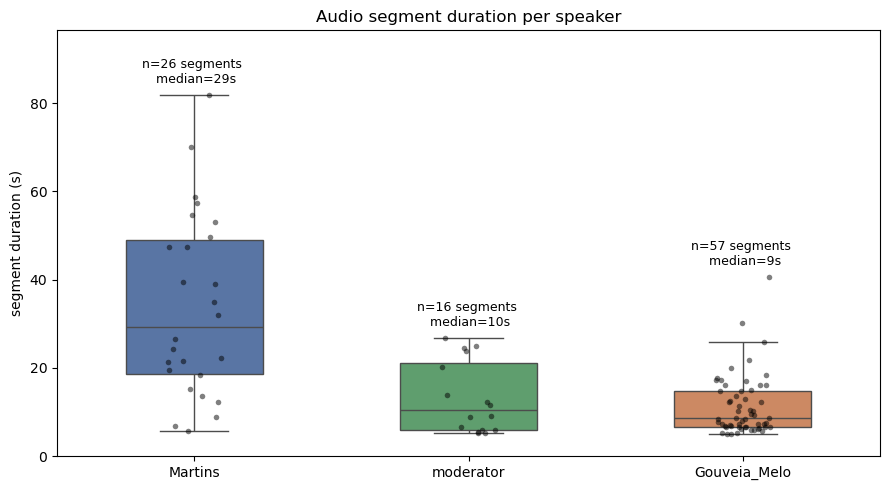

In [178]:
# plot the distribution of segment durations per speaker 
palette = ['#55A868', '#DD8452', '#4C72B0']

dur = pd.DataFrame({'speaker': owner, 'duration': df_audio['duration']}).dropna()
order = dur.groupby('speaker')['duration'].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=dur, x='speaker', y='duration', order=order, hue='speaker', 
            legend=False, palette=palette, width=0.5, showfliers=False, ax=ax)
sns.stripplot(data=dur, x='speaker', y='duration', order=order, 
              color='black', alpha=0.5, size=4, ax=ax)

for i, sp in enumerate(order):
    d = dur[dur['speaker'] == sp]['duration']
    ax.text(i, d.max() + 2, f'n={len(d)} segments \n median={d.median():.0f}s', ha='center', va='bottom', fontsize=9)

ax.set_title('Audio segment duration per speaker')
ax.set_xlabel('')
ax.set_ylabel('segment duration (s)')
ax.set_ylim(0, dur['duration'].max() * 1.18)
plt.tight_layout()
plt.show()

**Segment-length asymmetry and its impact.**

The plot shows that Martins's audio segments are much longer than Gouveia Melo's. That means, Martins tends to give uninterrupted answers, while Gouveia Melo speaks in shorter bursts (or speaker-diarization problems). This has two consequences for the segment-level analysis that follows:

- First, because we summarise each segment by averaging the speaker's emotion and pose over all its frames, longer segments are represented by flatter, more heavily-averaged values: within-segment emotional/pose variation is washed out more for Martins than for Gouveia Melo. The two candidates' segment-level observations are therefore not perfectly comparable —> Martins's points are coarser summaries of a longer span of behaviour.

- Second, the asymmetry produces an imbalanced number of observations (far fewer segments for Martins), which limits statistical analysis.

We keep the segment as the unit of analysis nonetheless, because the audio features are only defined per segment and splitting them would duplicate identical audio values. 

In [179]:
def collapse(df, key='segment_id'):
    '''Collapse frame-level data to segment-level.'''
    agg = {c: 'mean' for c in emotion_cols + pose_feature_cols} # face features: average over the segment
    agg.update({c: 'first' for c in NON_REDUNDANT}) # audio: same value all segment
    agg['seg_speaker'] = 'first'
    agg['final_name'] = 'first'
    agg['frame_number'] = 'count'
    out = (df.groupby(key).agg(agg).rename(columns={'frame_number': 'n_frames'}).reset_index())
    out['dom_emotion'] = out[emotion_cols].idxmax(axis=1).str.replace('prob_', '', regex=False)
    return out

# one row per segment = the speaker's own face paired with their own audio
seg = collapse(df_all[df_all['speaking_face']])

print('segments:', len(seg))
print(seg['final_name'].value_counts())
seg.head(3)

segments: 96
final_name
Gouveia_Melo    57
Martins         26
moderator       13
Name: count, dtype: int64


,segment_id,prob_Anger,prob_Contempt,prob_Disgust,prob_Fear,prob_Happiness,prob_Neutral,prob_Sadness,prob_Surprise,shoulder_slope,...,localShimmer,speechrate,npause,f1_mean,f2_mean,fdisp,seg_speaker,final_name,n_frames,dom_emotion
0,0,0.234670,0.045494,0.037876,0.021084,0.044083,0.334377,0.064523,0.217892,10.624308,...,0.093432,5.352778,0.0,485.749378,1472.416434,1125.196654,moderator,moderator,12,Neutral
1,1,0.157066,0.101884,0.206285,0.010895,0.127291,0.141335,0.240233,0.015011,2.916877,...,0.117677,3.364905,5.0,434.103941,1406.733051,1049.494681,Gouveia_Melo,Gouveia_Melo,14,Sadness
2,2,0.181409,0.127840,0.194301,0.020827,0.015022,0.110883,0.276151,0.073568,3.896072,...,0.117521,3.769239,2.0,428.787999,1396.907040,1035.080816,Gouveia_Melo,Gouveia_Melo,10,Sadness


## Auxiliar

In [180]:
emotion_colors = {'Anger':'tab:red','Happiness':'tab:olive','Neutral':'tab:gray',
                  'Sadness':'tab:blue','Surprise':'tab:orange','Fear':'tab:purple',
                  'Disgust':'tab:green','Contempt':'tab:brown'}
emotion_order  = ['Anger','Disgust','Contempt','Fear','Sadness','Surprise','Happiness','Neutral']


## A. Visual ↔ Visual  (frame level -> one row per face)

In [181]:
# identified faces (drop 'uncertain'); reused by every frame-level visual analysis
ident = df_all[df_all['final_name'].notna() & (df_all['final_name'] != 'uncertain')].copy()

# people present in this debate
mods   = [p for p in ident['final_name'].unique() if p == 'moderator']
people = sorted(p for p in ident['final_name'].unique() if p != 'moderator') + mods
print('people in this debate:', people)

people in this debate: ['Gouveia_Melo', 'Martins', 'moderator']


### A1. Emotion distribution per candidate

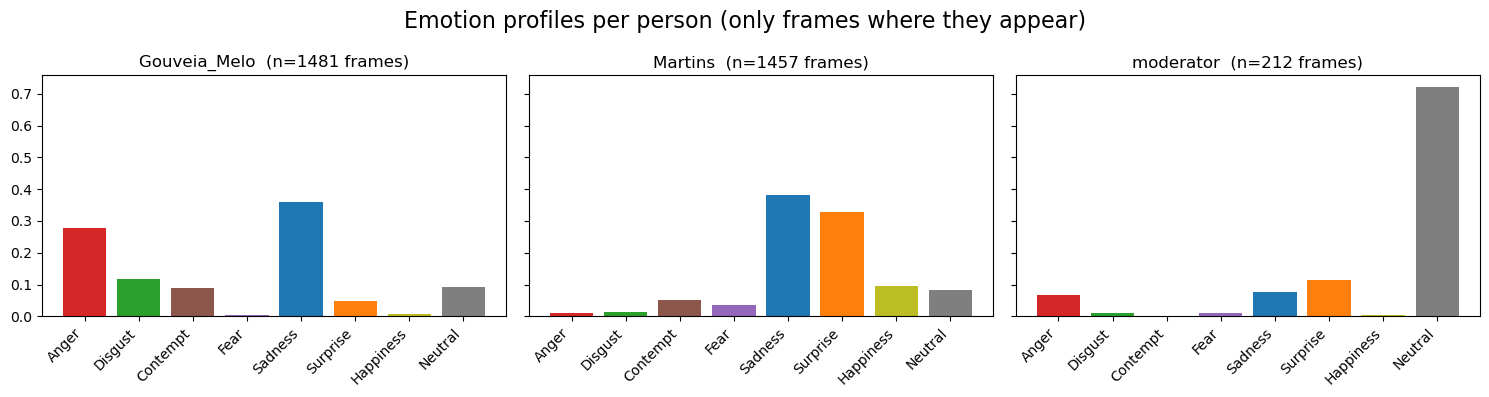

In [182]:
fig, axes = plt.subplots(1, len(people), figsize=(5*len(people), 4), sharey=True)
axes = np.atleast_1d(axes)

for ax, p in zip(axes, people):

    person_rows = ident[ident['final_name'] == p] # all frames where person p appears
    emotions = person_rows['top_emotion'] 

    prop = emotions.value_counts(normalize=True) # proportion of frames per emotion (summing to 1)
    prop = prop.reindex(emotion_order, fill_value=0) # order by emotion_order, filling missing emotions with 0

    ax.bar(range(len(emotion_order)), prop.values,color=[emotion_colors[e] for e in emotion_order])
    ax.set_title(f'{p}  (n={len(person_rows)} frames)')
    ax.set_xticks(range(len(emotion_order)))
    ax.set_xticklabels(emotion_order, rotation=45, ha='right')

plt.suptitle('Emotion profiles per person (only frames where they appear)', fontsize=16)
plt.tight_layout()
plt.show()

### A2. Emotions over time

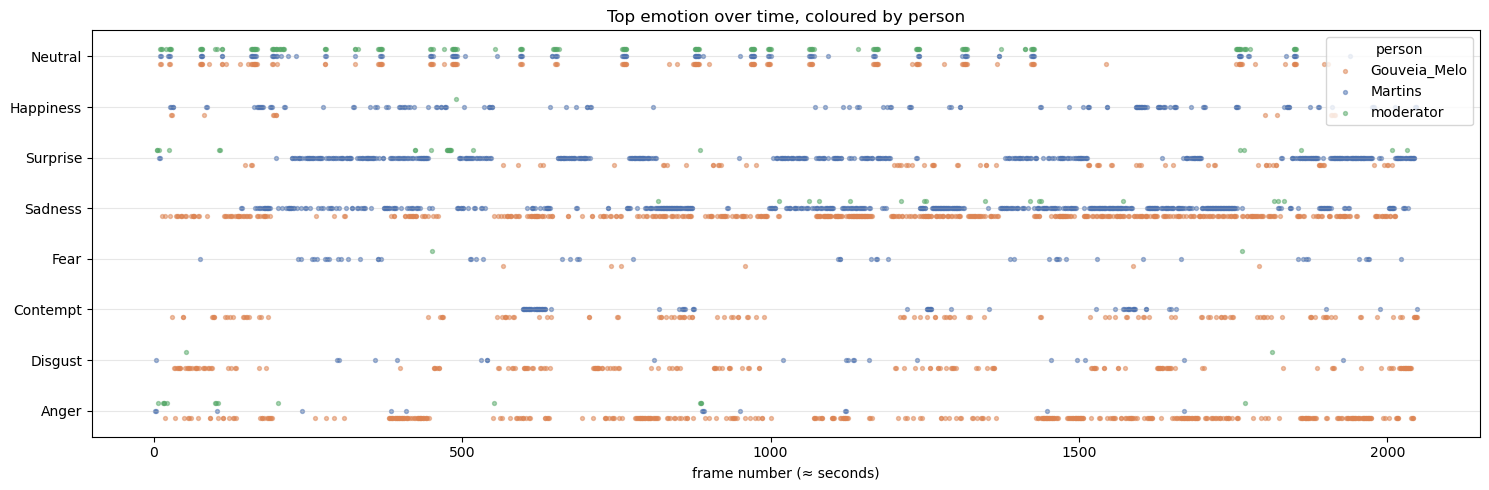

In [183]:
palette = [ '#DD8452', '#4C72B0',  '#55A868']

person_colors = {p: palette[i] for i, p in enumerate(people)}

y_pos = {e: i for i, e in enumerate(emotion_order)}
# small vertical offset per person so they don't sit exactly on top of each other in a lane
offsets = dict(zip(people, [-0.15, 0, 0.15]))

fig, ax = plt.subplots(figsize=(15, 5))
for p in people:
    sub = ident[ident['final_name'] == p]
    y = sub['top_emotion'].map(y_pos) + offsets[p]
    ax.scatter(sub['frame_number'], y, s=8, alpha=0.5, color=person_colors[p], label=p)

ax.set_yticks(range(len(emotion_order)))
ax.set_yticklabels(emotion_order)
ax.set_xlabel('frame number (≈ seconds)')
ax.set_title('Top emotion over time, coloured by person')
ax.legend(title='person')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### A3. Poses and emotions

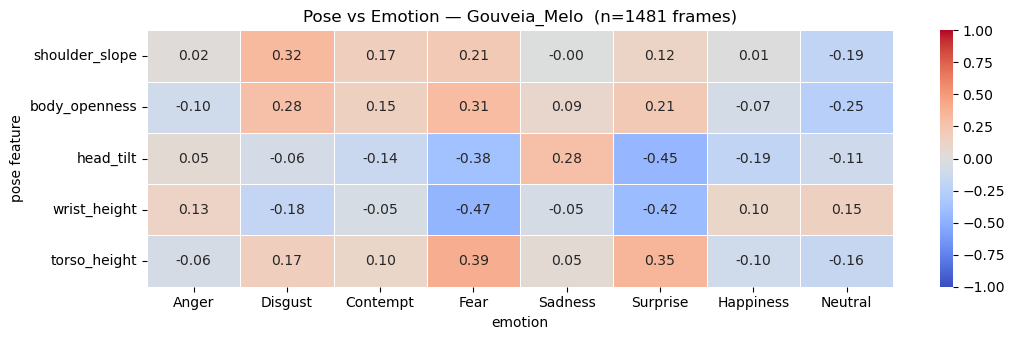

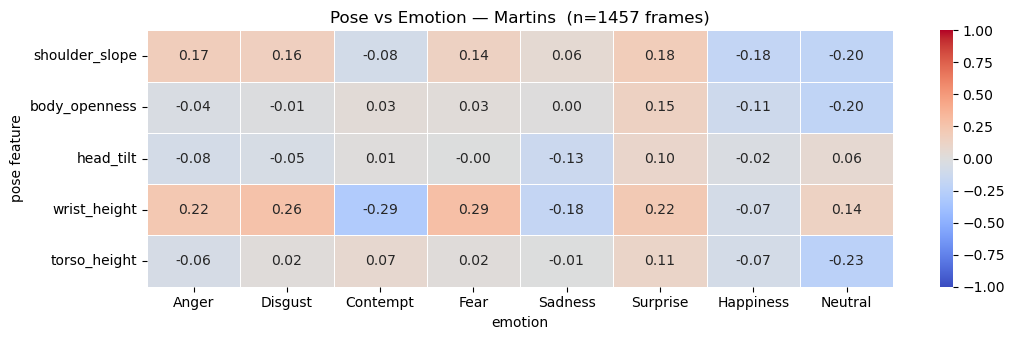

In [184]:
# Doing for each cand to accout for camera angle differences, body propotions, etc. 

cands = [p for p in people if p != 'moderator']

sub = ident[ident['final_name'].isin(cands)] 

ordered_prob = [f'prob_{e}' for e in emotion_order]

for p in cands:
    sub = ident[ident['final_name'] == p]
    cc = sub[pose_feature_cols + ordered_prob].corr('spearman').loc[pose_feature_cols, ordered_prob]
    cc.columns = emotion_order
    plt.figure(figsize=(11, 3.5))
    sns.heatmap(cc, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=.5)
    plt.title(f'Pose vs Emotion — {p}  (n={len(sub)} frames)')
    plt.xlabel('emotion'); plt.ylabel('pose feature')
    plt.tight_layout(); plt.show()

### A4. Emotion co-occurrence between the two candidates in shared frames

frames with BOTH candidates on screen: 1012


/var/folders/5g/t8kckpys61zdtmy3jx9lt0z00000gn/T/ipykernel_5184/3417022056.py:23: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  expected = ct.sum(1).values.reshape(-1, 1) @ ct.sum(0).values.reshape(1, -1) / total # expected counts under independence = (row total * column total) / grand total
/var/folders/5g/t8kckpys61zdtmy3jx9lt0z00000gn/T/ipykernel_5184/3417022056.py:23: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  expected = ct.sum(1).values.reshape(-1, 1) @ ct.sum(0).values.reshape(1, -1) / total # expected counts under independence = (row total * column total) / grand total


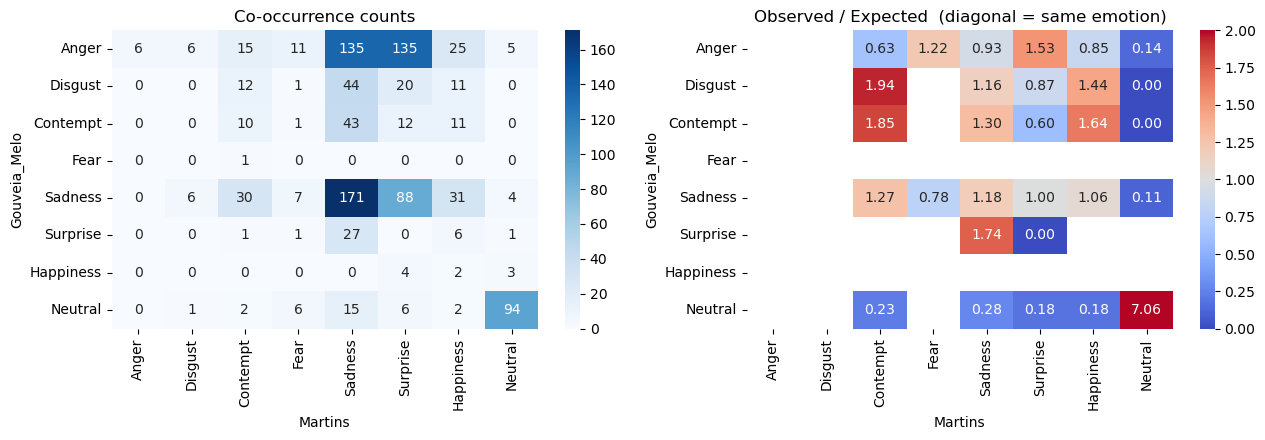

chi2=749.9  p=3.74e-126  Cramér V=0.325


In [185]:
cands = [p for p in people if p != 'moderator']
g, m = cands[0], cands[1]

sub = ident[ident['final_name'].isin(cands)] # only frames where we see either candidate

# one emotion per (frame, person)
per_frame_person = sub.groupby(['frame_number', 'final_name'])['top_emotion'].first()
# pivot persons into columns -> one row per frame, one column per candidate
piv = per_frame_person.unstack('final_name')

both = piv.dropna(subset=cands)
print('frames with BOTH candidates on screen:', len(both))

# only keep emotions that appear at least 10 times for either candidate, to avoid noisy values from very rare emotions
keep = []
for e in emotion_order:
    if (both[g] == e).sum() >= 10 or (both[m] == e).sum() >= 10:
        keep.append(e)
ct = pd.crosstab(both[g], both[m]).reindex(index=keep, columns=keep, fill_value=0)

total = ct.values.sum() # total frames with both candidates and a valid emotion

expected = ct.sum(1).values.reshape(-1, 1) @ ct.sum(0).values.reshape(1, -1) / total # expected counts under independence = (row total * column total) / grand total

lift = (ct / expected.clip(min=1e-9)).mask(expected < 5) # observed / expected
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Co-occurrence counts')
sns.heatmap(lift, annot=True, fmt='.2f', cmap='coolwarm', center=1, vmin=0, vmax=2, ax=axes[1])
axes[1].set_title('Observed / Expected  (diagonal = same emotion)')

for ax in axes:
    ax.set_xlabel(m)
    ax.set_ylabel(g)
plt.tight_layout() 
plt.show()

from scipy.stats import chi2_contingency
chi2, p, dof, _ = chi2_contingency(ct)
v = np.sqrt(chi2 / (total * (min(ct.shape) - 1)))
print(f'chi2={chi2:.1f}  p={p:.3g}  Cramér V={v:.3f}')

/var/folders/5g/t8kckpys61zdtmy3jx9lt0z00000gn/T/ipykernel_5184/3427593865.py:9: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  exp2 = ct2.sum(1).values.reshape(-1, 1) @ ct2.sum(0).values.reshape(1, -1) / total2
/var/folders/5g/t8kckpys61zdtmy3jx9lt0z00000gn/T/ipykernel_5184/3427593865.py:9: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  exp2 = ct2.sum(1).values.reshape(-1, 1) @ ct2.sum(0).values.reshape(1, -1) / total2


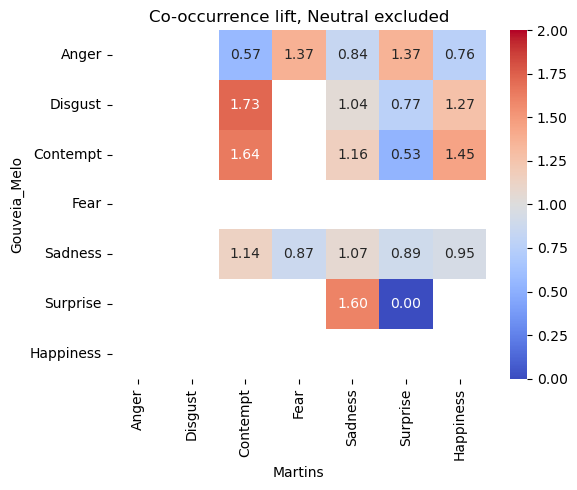

expressive-only: chi2=98.9  p=8.83e-08  Cramér V=0.137


In [186]:
# without Neutral, to see if there's a stronger association between the more expressive emotions 
expr = []
for e in ct.index:
    if e != 'Neutral':
        expr.append(e)

ct2 = ct.loc[expr, expr]
total2 = ct2.values.sum()
exp2 = ct2.sum(1).values.reshape(-1, 1) @ ct2.sum(0).values.reshape(1, -1) / total2
lift2 = (ct2 / exp2.clip(min=1e-9)).mask(exp2 < 5)

plt.figure(figsize=(6, 5))
sns.heatmap(lift2, annot=True, fmt='.2f', cmap='coolwarm', center=1, vmin=0, vmax=2)
plt.title('Co-occurrence lift, Neutral excluded'); plt.xlabel(m); plt.ylabel(g)
plt.tight_layout(); plt.show()

from scipy.stats import chi2_contingency
chi2b, pb, _, _ = chi2_contingency(ct2)
print(f'expressive-only: chi2={chi2b:.1f}  p={pb:.3g}  Cramér V={np.sqrt(chi2b/(total2*(min(ct2.shape)-1))):.3f}')

## B. Audio ↔ Visual  (segment level —> one row per segment)

### B1. Audio ↔ Emotion

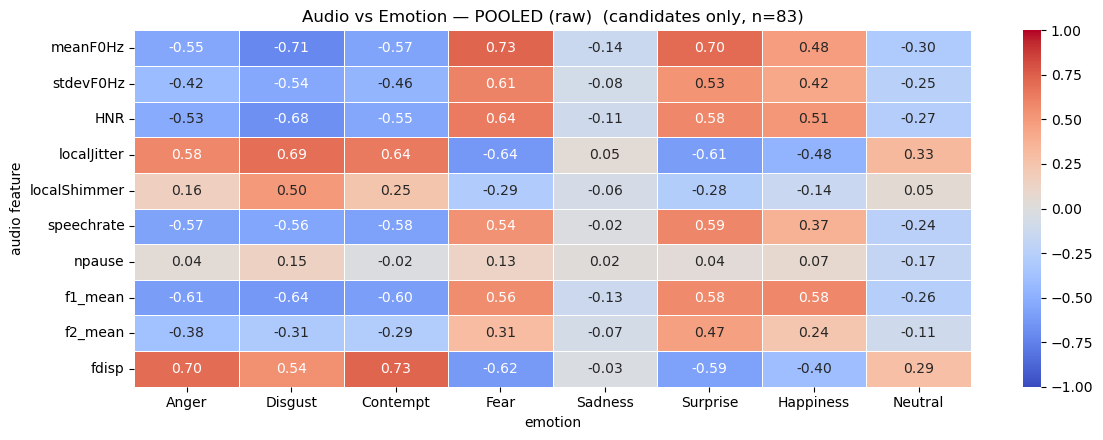

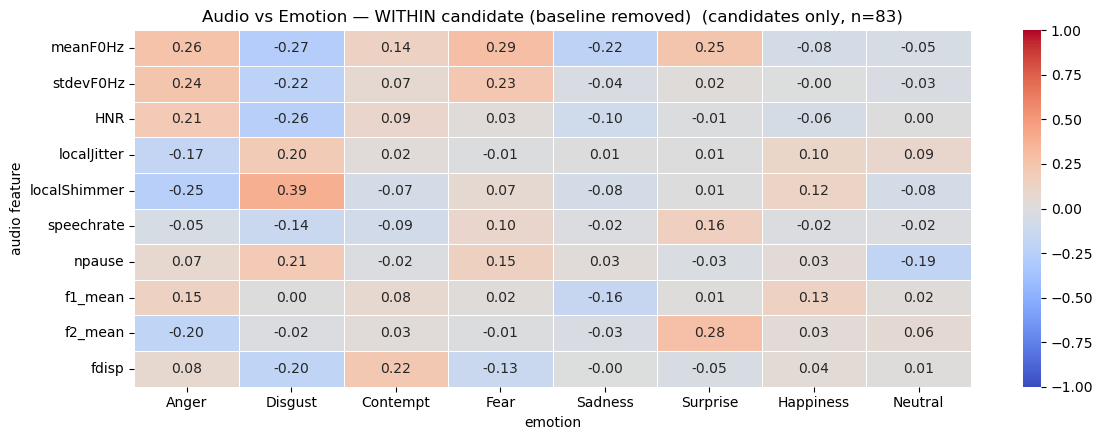

In [187]:
cands = [p for p in people if p != 'moderator']
segc = seg[seg['final_name'].isin(cands)].copy()
ordered_prob = [f'prob_{e}' for e in emotion_order]

# POOLED
pooled = segc[NON_REDUNDANT + ordered_prob].corr('spearman').loc[NON_REDUNDANT, ordered_prob]

# WITHIN candidate: remove each candidate's own mean first (kills voice/sex baseline)
cen = segc.copy()
for col in NON_REDUNDANT + ordered_prob:
    cen[col] = segc[col] - segc.groupby('final_name')[col].transform('mean')
within = cen[NON_REDUNDANT + ordered_prob].corr('spearman').loc[NON_REDUNDANT, ordered_prob]

for mat, ttl in [(pooled, 'POOLED (raw)'), (within, 'WITHIN candidate (baseline removed)')]:
    mat.columns = emotion_order
    plt.figure(figsize=(12, 4.5))
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=.5)
    plt.title(f'Audio vs Emotion — {ttl}  (candidates only, n={len(segc)})')
    plt.xlabel('emotion'); plt.ylabel('audio feature')
    plt.tight_layout(); plt.show()

### B5. Audio ↔ Pose (speaking face only)

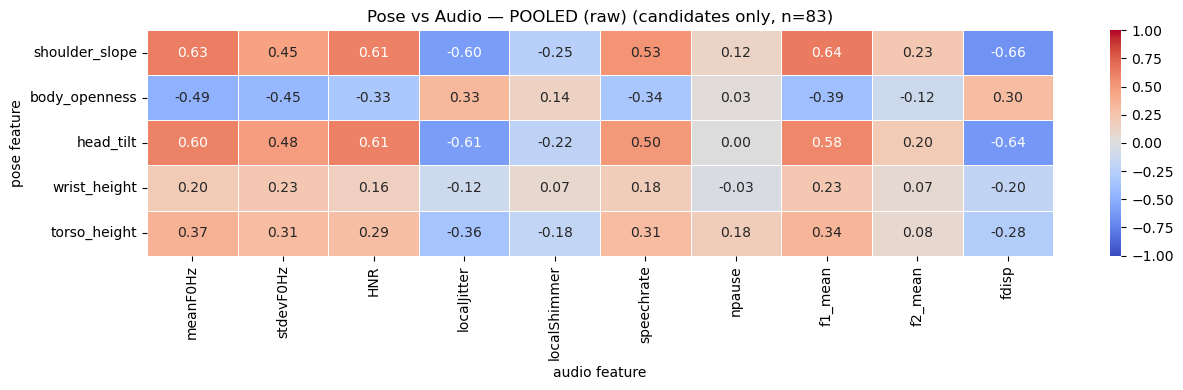

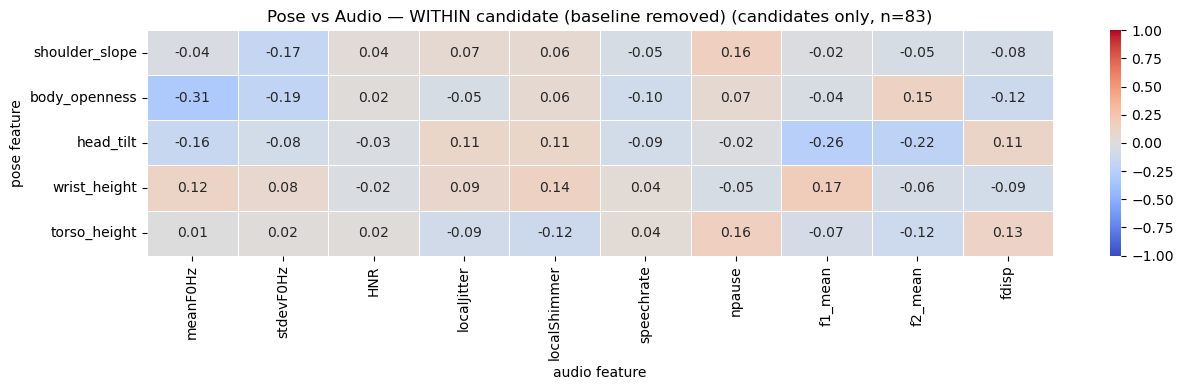

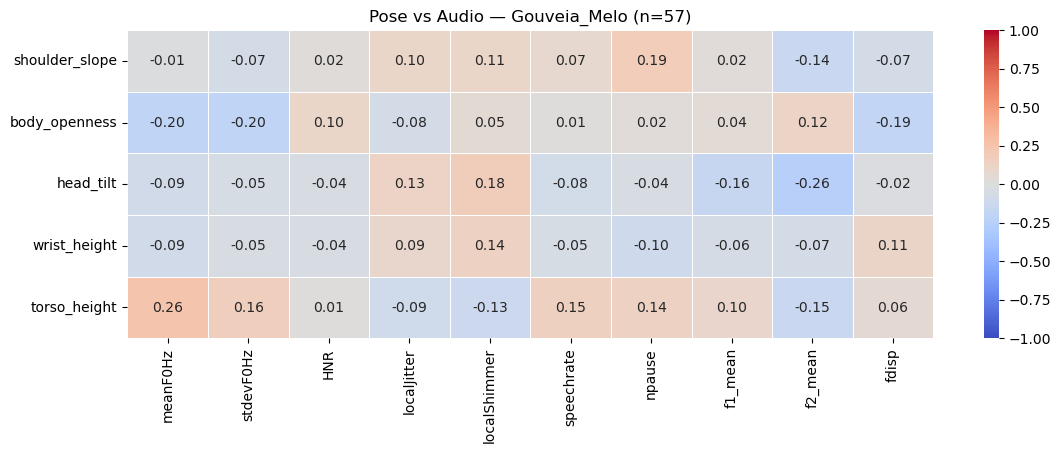

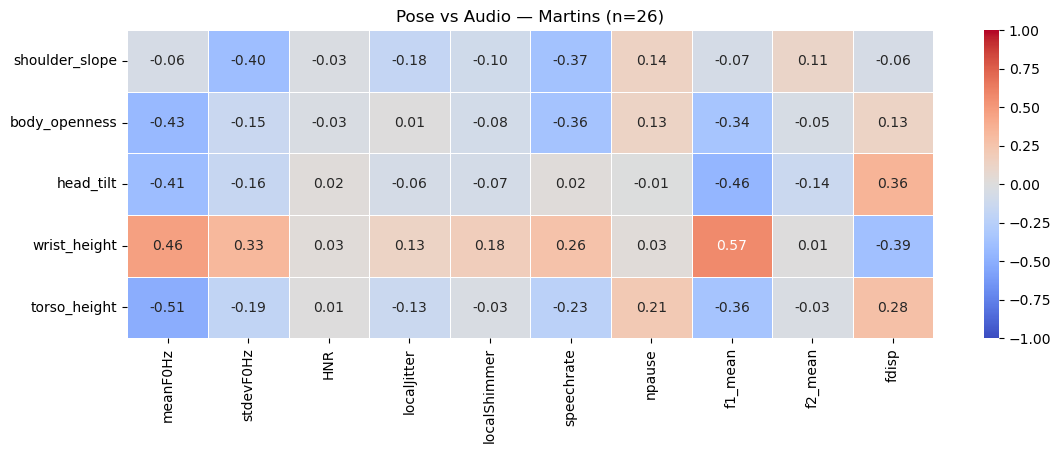

In [188]:
cands = [p for p in people if p != 'moderator']
segc = seg[seg['final_name'].isin(cands)].copy()

# POOLED (raw)
pooled = segc[pose_feature_cols + NON_REDUNDANT].corr('spearman').loc[pose_feature_cols, NON_REDUNDANT]

# WITHIN candidate (remove each candidate's own mean first)
cen = segc.copy()
for col in pose_feature_cols + NON_REDUNDANT:
    cen[col] = segc[col] - segc.groupby('final_name')[col].transform('mean')
within = cen[pose_feature_cols + NON_REDUNDANT].corr('spearman').loc[pose_feature_cols, NON_REDUNDANT]

for mat, ttl in [(pooled, 'POOLED (raw)'), (within, 'WITHIN candidate (baseline removed)')]:
    plt.figure(figsize=(13, 4))
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=.5)
    plt.title(f'Pose vs Audio — {ttl} (candidates only, n={len(segc)})')
    plt.xlabel('audio feature'); plt.ylabel('pose feature')
    plt.tight_layout(); plt.show()

# separate the 2 candidates in 2 different plots
for cand in cands:
    sub = segc[segc['final_name'] == cand]
    mat = sub[pose_feature_cols + NON_REDUNDANT].corr('spearman').loc[pose_feature_cols, NON_REDUNDANT]
    plt.figure(figsize=(13, 4))
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=.5)
    plt.title(f'Pose vs Audio — {cand} (n={len(sub)})')